pip install stable-baselines3[extra] gymnasium[atari]


In [1]:
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv  # Windows 兼容: DummyVecEnv 不使用子进程
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子，保证可复现
import random
random.seed(42)
np.random.seed(42)

# 1. 创建多个并行环境
num_envs = 4
def make_env(seed):
    def _init():
        e = gym.make('CartPole-v1')
        e.reset(seed=seed)
        return e
    return _init

env = DummyVecEnv([make_env(42 + i) for i in range(num_envs)])

# 2. 初始化 PPO 模型（优化超参数）
model = PPO(
    "MlpPolicy",
    env,
    learning_rate=0.0003, 
    gamma=0.99, 
    ent_coef=0.01,  # 正确方式 增加探索
    clip_range=0.2,      # 让训练更稳定
    verbose=0,
    seed=42,
)

# 3. 训练模型（训练更久）
model.learn(total_timesteps=500_000)

# 4. 保存模型
model.save("./data/ppo_cartpole")


c:\Users\崔崟\anaconda3\envs\py_gpu_new\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


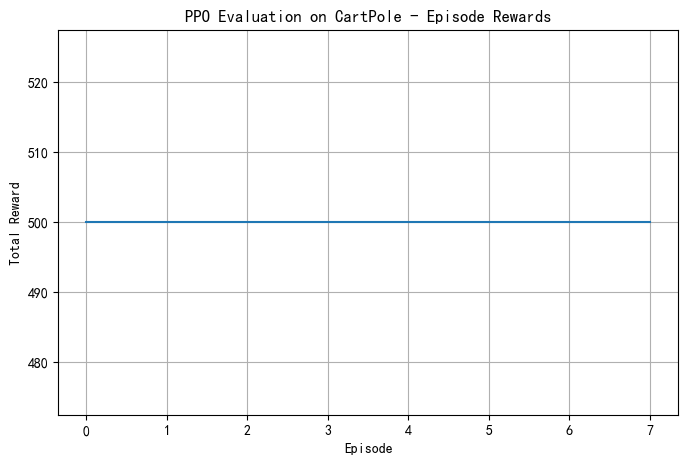

In [2]:
import numpy as np

# 5. 载入模型
model = PPO.load("./data/ppo_cartpole")

# 6. 评估训练好的模型
obs = env.reset()
rewards = np.zeros(num_envs)  # 记录每个环境当前回合的累计奖励
episode_rewards = []  # 存储已完成回合的奖励

for _ in range(1000):  # 运行1000步
    action, _ = model.predict(obs)
    obs, reward, done, info = env.step(action)

    rewards += reward  # 累积当前回合奖励

    # 逐个检查已完成的环境
    for i in range(num_envs):
        if done[i]:
            episode_rewards.append(rewards[i])  # 记录本回合总奖励
            rewards[i] = 0  # 重置该环境的回合奖励

# env.close()

# 7. 绘制每个回合的奖励变化
plt.figure(figsize=(8, 5))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("PPO Evaluation on CartPole - Episode Rewards")
plt.grid(True)
plt.show()
